In [1]:
import pandas as pd



In [2]:
#import intersection data and see where we start with cleaning
intersection = pd.read_csv("tmc_raw_data_2020_2029.csv")
intersection.head(5)

intersection_d = intersection.drop(columns=[
    "_id",
    "centreline_type",
    "centreline_id"
], errors="ignore")

intersection_d.head(5)

,count_id,count_date,location_name,longitude,latitude,px,start_time,end_time,n_appr_cars_r,n_appr_cars_t,...,w_appr_bus_t,w_appr_bus_l,n_appr_peds,s_appr_peds,e_appr_peds,w_appr_peds,n_appr_bike,s_appr_bike,e_appr_bike,w_appr_bike
0,39575,2020-02-12,Arrow Rd / Deerhide Cres (North),-79.532792,43.749488,NaN,2020-02-12T07:30:00,2020-02-12T07:45:00,12,132,...,0,0,0,0,0,1,0,0,0,0
1,39655,2020-03-10,Weston Rd / John St,-79.517790,43.700601,581.0,2020-03-10T13:15:00,2020-03-10T13:30:00,0,77,...,0,0,10,25,46,0,0,0,0,0
2,39471,2020-01-28,Lascelles Blvd / Gormley Ave,-79.399207,43.694278,NaN,2020-01-28T07:30:00,2020-01-28T07:45:00,0,0,...,0,0,2,0,0,1,1,0,0,0
3,39471,2020-01-28,Lascelles Blvd / Gormley Ave,-79.399207,43.694278,NaN,2020-01-28T07:45:00,2020-01-28T08:00:00,0,0,...,0,0,4,0,2,6,0,0,0,0
4,39471,2020-01-28,Lascelles Blvd / Gormley Ave,-79.399207,43.694278,NaN,2020-01-28T08:00:00,2020-01-28T08:15:00,0,0,...,0,0,1,0,0,2,0,0,0,0


In [3]:
intersection_d[["px"]].isnull().mean() *100
intersection_d.groupby("count_id").size()

#change data type for time
intersection_d[["start_time", "end_time"]].dtypes
intersection_d["start_time"] = pd.to_datetime(intersection_d["start_time"], errors="coerce")
intersection_d["end_time"] = pd.to_datetime(intersection_d["end_time"], errors="coerce")
intersection_d[["start_time", "end_time"]].isnull().sum()



start_time    0
end_time      0
dtype: int64

In [4]:
#get duration
intersection_d["duration_hours"] = (
    (intersection_d["end_time"] - intersection_d["start_time"])
    .dt.total_seconds() / 3600
)
intersection_d["duration_hours"].value_counts().sort_index()

duration_hours
0.25    336030
Name: count, dtype: int64

In [5]:
#look at values with the same location and same date and same start time, drop duplicates

intersection_d = intersection_d.drop_duplicates(
    subset=["location_name", "count_date", "start_time"],
    keep="first"
)
intersection_d.groupby(["location_name", "count_date", "start_time"]).size().value_counts()


1    335566
Name: count, dtype: int64

In [7]:
location_counts = intersection_d.groupby("location_name").size()
location_counts.sort_values(ascending=False).head(10)

location_name
St Clair Ave E / Yonge St / St Clair Ave W                       976
Yonge St / Davisville Ave / Chaplin Cres                         952
Avenue Rd / Queen's Park / Bloor St W                            848
Mount Pleasant Rd / St Clair Ave E                               752
Bloor St E / Yonge St / Bloor St W                               736
Avenue Rd / Chaplin Cres                                         736
Davenport Rd / Yonge St / Church St                              721
Mount Pleasant Rd / Jarvis St / Ted Rogers Way / Charles St E    704
Danforth Ave / Victoria Park Ave                                 680
Mount Pleasant Rd / Davisville Ave (West)                        672
dtype: int64

In [8]:
time = intersection_d.groupby("start_time").value_counts().describe()
print(time)

count    233893.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: count, dtype: float64


In [9]:
intersection_d["start_time_day"] = intersection_d["start_time"].dt.time
intersection_d["end_time_day"] = intersection_d["end_time"].dt.time

In [10]:
#chekc out when exactly things start and end
intersection_d["start_time_day"].min()
intersection_d["start_time_day"].max()

datetime.time(23, 45)

In [11]:
intersection_d.to_csv("tmc_cleaned.csv", index=False)

In [ ]:
#aggregate intersection bike count
intersection_d["bike_count"] = intersection_d["n_appr_bike"]+intersection_d["s_appr_bike"]+intersection_d["e_appr_bike"]+intersection_d["w_appr_bike"]
intersection_bike = (
    intersection_d
    .groupby("location_name")["bike_count"]
    .mean()
    .reset_index(name="avg_15min_bike")
)

print(intersection_bike)

                                          location_name  avg_15min_bike
0                                 Abell St / Sudbury St        6.781250
1                            Acacia Rd / Davisville Ave        1.261364
2                       Acacia Rd / Millwood Rd (North)        1.011364
3                       Acacia Rd / Millwood Rd (South)        0.465909
4                              Acorn Ave / Montesson St        0.125000
...                                                 ...             ...
3974                               York St / Station St       19.105263
3975                          York St / Wellington St W       16.428571
3976  Yorkdale Park Trl / Yorkdale Rd / Yorkdale S A...        0.803571
3977  Yorkdale Rd: Hwy 401 Collectors E / Yorkdale R...        0.017857
3978  Zoo Rd: Zoo Meadowvale Rd N Ramp - Zoo Meadowv...        0.062500

[3979 rows x 2 columns]


In [42]:
pd.set_option("display.max_colwidth", None)
intersection_bike[
    ["location_name", "avg_15min_bike"]
].sort_values(
    by="avg_15min_bike",
    ascending=False
).head(5)

,location_name,avg_15min_bike
2271,Lower Simcoe St / Queens Quay W / Martin Goodman Trl,143.375000
239,Bathurst St / Queens Quay W / Eireann Quay / Little Norway Park Trl / Martin Goodman Trl,122.169643
500,Bloor St W / St George St,121.366071
510,Bloor St W / Walmer Rd / Robert St,104.553571
3555,University Ave / Richmond St W,100.714286


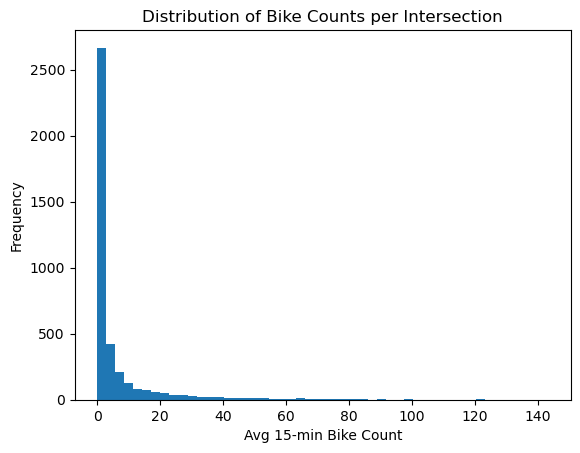

In [ ]:
#check intersection bike count distribution
import matplotlib.pyplot as plt

plt.hist(intersection_bike["avg_15min_bike"], bins=50)
plt.xlabel("Avg 15-min Bike Count")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Counts per Intersection")
plt.show()

In [ ]:
#define threshold at 80%
threshold = intersection_bike["avg_15min_bike"].quantile(0.8)
print(threshold)

6.78125


In [ ]:
#keep one observation for each combination
coords = intersection_d[["location_name", "latitude", "longitude"]].drop_duplicates()

intersection_bike_geo = intersection_bike.merge(
    coords,
    on="location_name",
    how="left"
)
#test null
intersection_bike_geo.value_counts()

location_name                                                avg_15min_bike  latitude   longitude 
Zoo Rd: Zoo Meadowvale Rd N Ramp - Zoo Meadowvale Rd S Ramp  0.062500        43.818250  -79.173725    1
Abell St / Sudbury St                                        6.781250        43.641125  -79.423587    1
Acacia Rd / Davisville Ave                                   1.261364        43.699748  -79.389640    1
Acacia Rd / Millwood Rd (North)                              1.011364        43.701139  -79.389906    1
Acacia Rd / Millwood Rd (South)                              0.465909        43.700725  -79.390017    1
                                                                                                     ..
Adelaide St W / Sheppard St                                  19.660714       43.649615  -79.382131    1
Adelaide St W / Simcoe St                                    83.875000       43.648638  -79.386621    1
Adelaide St W / York St                                      50.50000

In [17]:
#3979 observations went to 4242 after merge, let us see what is wrong
dupes = coords["location_name"].value_counts()
problem_locs = dupes[dupes > 1].index

In [18]:
problem_rows = (
    intersection_d[
        intersection_d["location_name"].isin(problem_locs)
    ][["location_name", "latitude", "longitude"]]
    .drop_duplicates()
    .sort_values("location_name")
)

problem_rows
#very similar coordinates, use average

,location_name,latitude,longitude
163280,Albion Ave / Pharmacy Ave,43.695636,-79.284806
155833,Albion Ave / Pharmacy Ave,43.695636,-79.284806
155249,Albion Rd / Humber River Recreational Trl / We...,43.717655,-79.539093
158489,Albion Rd / Humber River Recreational Trl / We...,43.717679,-79.539087
161661,Allen Rd / Eglinton Ave W (East),43.698990,-79.435033
...,...,...,...
160063,Yonge St / Gerrard St E / Gerrard St W,43.659094,-79.382105
33305,Yonge St / Merton St,43.696127,-79.396205
165668,Yonge St / Merton St,43.696115,-79.396170
163697,Yonge St / The Esplanade,43.645784,-79.376503


In [19]:
coords_new = (
    intersection_d
    .groupby("location_name", as_index=False)[["latitude", "longitude"]]
    .mean()
)
intersection_bike_geo = intersection_bike.merge(
    coords_new,
    on="location_name",
    how="left"
)
intersection_bike_geo.value_counts()

location_name                                                avg_15min_bike  latitude   longitude 
Zoo Rd: Zoo Meadowvale Rd N Ramp - Zoo Meadowvale Rd S Ramp  0.062500        43.818250  -79.173725    1
Abell St / Sudbury St                                        6.781250        43.641125  -79.423587    1
Acacia Rd / Davisville Ave                                   1.261364        43.699748  -79.389640    1
Acacia Rd / Millwood Rd (North)                              1.011364        43.701139  -79.389906    1
Acacia Rd / Millwood Rd (South)                              0.465909        43.700725  -79.390017    1
                                                                                                     ..
Adelaide St E / Yonge St / Adelaide St W                     36.145833       43.650422  -79.378426    1
Adelaide St W / Brant St / St. Andrew's Playground Trl       37.727273       43.646224  -79.398127    1
Adelaide St W / Duncan St                                    59.28571

In [20]:
#now the bike lane data
import json
from shapely.geometry import shape
import geopandas as gpd # type: ignore

bike_lanes = pd.read_csv("cycling-network - 4326 (1).csv")
bike_lanes["geometry"] = bike_lanes["geometry"].apply(json.loads)
bike_lanes["geometry"] = bike_lanes["geometry"].apply(shape)
bike_lanes_map = gpd.GeoDataFrame(bike_lanes, geometry="geometry", crs="EPSG:4326")





<Axes: >

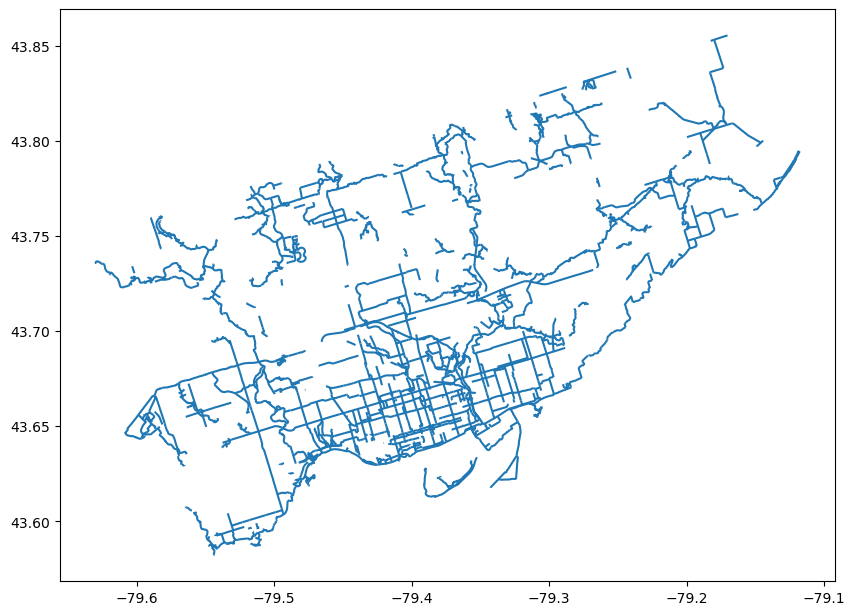

In [21]:
bike_lanes_map.plot(figsize=(10,10))

In [ ]:
#map intersection data
intersections_gdf = gpd.GeoDataFrame(
    intersection_bike_geo,
    geometry=gpd.points_from_xy(
        intersection_bike_geo["longitude"],
        intersection_bike_geo["latitude"]
    ),
    crs="EPSG:4326"
)

<Axes: >

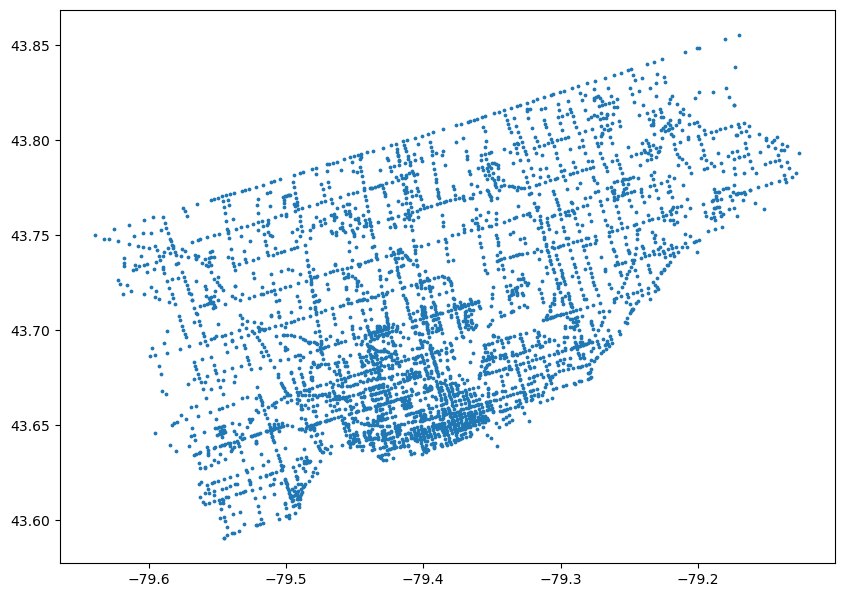

In [23]:
intersections_gdf.plot(figsize=(10, 10), markersize=3)

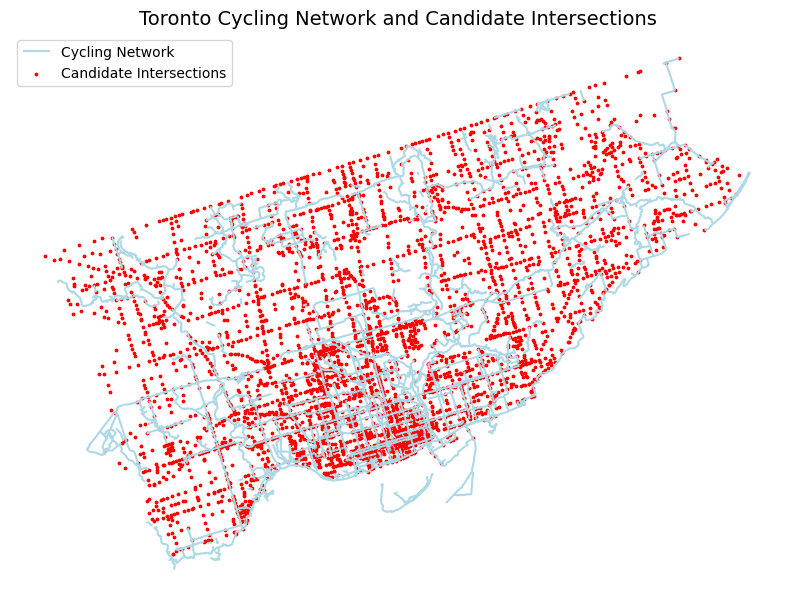

In [ ]:
#join the two graphs

ax = bike_lanes_map.plot(
    figsize=(10, 10),
    color="lightblue",
    label="Cycling Network"
)

intersections_gdf.plot(
    ax=ax,
    color="red",
    markersize=3,
    label="Candidate Intersections"
)

ax.set_title(
    "Toronto Cycling Network and Candidate Intersections",
    fontsize=14
)

ax.legend()
ax.set_axis_off()

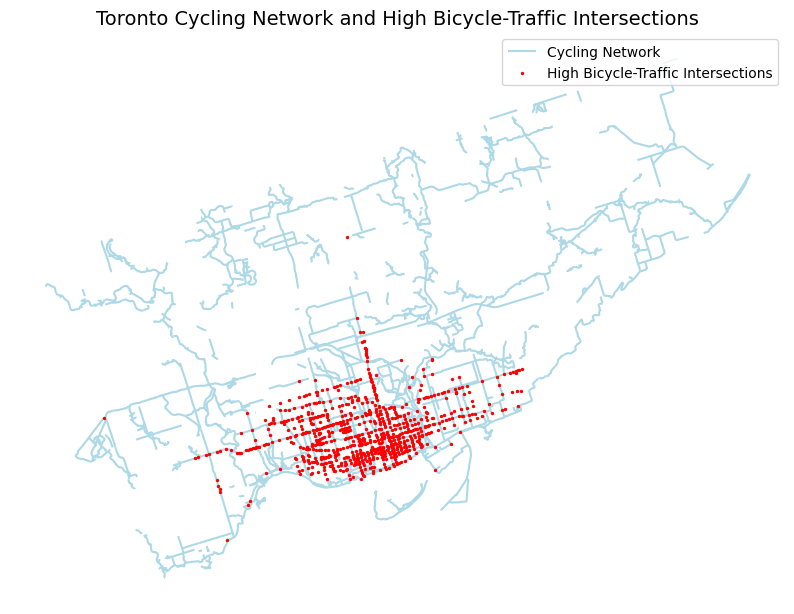

In [ ]:
#filter out the top 20% intersections in biker volume
ax = bike_lanes_map.plot(
    figsize=(10, 10),
    color="lightblue",
    label="Cycling Network",
    zorder=1
)

high_bike.plot(
    ax=ax,
    color="red",
    markersize=2,
    label="High Bicycle-Traffic Intersections",
    zorder=2
)

ax.set_title(
    "Toronto Cycling Network and High Bicycle-Traffic Intersections",
    fontsize=14
)

ax.legend()
ax.set_axis_off()

plt.savefig(
    "high_bike_intersections.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#identify high-biker intersection that are also outside of buffer radius
intersections_gdf_3857 = intersections_gdf.to_crs(epsg=3857)
bike_lanes_gdf_3857 = bike_lanes_map.to_crs(epsg=3857)
high_bike_3857 = intersections_gdf_3857[
    intersections_gdf_3857["avg_15min_bike"] >= threshold]

buffer_radius =400
high_bike_3857["buffer"] = high_bike_3857.geometry.buffer(buffer_radius)
high_bike_buffered =high_bike_3857.set_geometry("buffer")

covered = gpd.sjoin(
    high_bike_buffered,
    bike_lanes_gdf_3857[["geometry"]],
    how="left",
    predicate="intersects"
)

uncovered = covered[covered["index_right"].isna()]

uncovered_points = high_bike_3857.loc[uncovered.index].copy()

print(f"Number of high-bike intersections without nearby bike lanes: {len(uncovered_points)}")
uncovered_points[["location_name", "avg_15min_bike"]].head(20)


Number of high-bike intersections without nearby bike lanes: 43


/Users/Emmett/.julia/conda/3/x86_64/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,location_name,avg_15min_bike
104,Atlantic Ave / Liberty St,12.937500
257,Bathurst St / Vaughan Rd / Helena Ave,9.321429
795,Coxwell Ave / Hanson St,7.562500
838,Danforth Ave / Kenworthy Ave,11.678571
993,Dovercourt Rd / Dundas St W,20.891667
997,Dovercourt Rd / Shanly St,10.906250
1033,Dufferin St / Liberty St,9.363636
1107,Dundas St W / Grace St,16.515625
1108,Dundas St W / High Park Ave,8.210938
1161,Dupont St / Spadina Rd,8.445652


In [ ]:
#rank the intersections based on volume
uncovered_points[
    ["location_name", "avg_15min_bike"]
].sort_values(
    by="avg_15min_bike",
    ascending=False
).head(20)

,location_name,avg_15min_bike
3235,Spadina Ave / Dundas St W,48.983553
3232,Spadina Ave / Baldwin St (North),37.406250
3243,Spadina Ave / St Andrew St,36.593750
2836,Queen St W / Lisgar St,23.250000
2793,Queen St E / Broadview Ave,23.098404
1939,King St W / Dufferin St,22.643229
1751,Isabella St / Church St,22.100806
993,Dovercourt Rd / Dundas St W,20.891667
1517,Gerrard St E / Boulton Ave,19.714286
1107,Dundas St W / Grace St,16.515625


In [27]:
#ranking them by how many people there are
priority_candidates = uncovered_points[[
    "location_name", "avg_15min_bike", "geometry"
]].sort_values("avg_15min_bike", ascending=False)

priority_candidates

,location_name,avg_15min_bike,geometry
3235,Spadina Ave / Dundas St W,48.983553,POINT (-8838549.871 5411888.751)
3232,Spadina Ave / Baldwin St (North),37.406250,POINT (-8838648.035 5412228.181)
3243,Spadina Ave / St Andrew St,36.593750,POINT (-8838613.824 5412113.068)
2836,Queen St W / Lisgar St,23.250000,POINT (-8841393.934 5410399.42)
2793,Queen St E / Broadview Ave,23.098404,POINT (-8833182.569 5412802.363)
1939,King St W / Dufferin St,22.643229,POINT (-8841814.456 5409738.942)
1751,Isabella St / Church St,22.100806,POINT (-8836766.358 5414258.878)
993,Dovercourt Rd / Dundas St W,20.891667,POINT (-8841517.033 5411351.161)
1517,Gerrard St E / Boulton Ave,19.714286,POINT (-8833137.376 5413920.855)
1107,Dundas St W / Grace St,16.515625,POINT (-8840315.084 5411545.569)


In [ ]:
#find nearest bikelane distance for high biker and no bike-lane intersections

nearest_uncovered = gpd.sjoin_nearest(
    uncovered_points,
    bike_lanes_gdf_3857[["geometry"]],
    how="left",
    distance_col="nearest_bike_lane_m"
)

nearest_uncovered_clean = (
    nearest_uncovered
    .reset_index()
    .sort_values("nearest_bike_lane_m")
    .drop_duplicates(subset="index", keep="first")
    .set_index("index")
)



nearest_uncovered_clean[["location_name", "avg_15min_bike", "nearest_bike_lane_m"]].sort_values(
    "nearest_bike_lane_m", ascending=False
)


,location_name,avg_15min_bike,nearest_bike_lane_m
index,,,
2008,Kingston Rd / Scarborough Rd,7.482143,937.821827
1961,Kingston Rd / Beech Ave,6.794643,820.812170
3318,St Clair Ave W / Via Italia,9.500000,797.093720
3321,St Clair Ave W / Westmount Ave (West),7.571429,795.364621
3305,St Clair Ave W / Northcliffe Blvd,7.669643,778.266313
3302,St Clair Ave W / McRoberts Ave / Earlscourt Pa...,8.321429,745.615597
3297,St Clair Ave W / Glenholme Ave (East),7.090278,701.064578
3720,Weston Rd / Keele St / St Clair Ave W,7.965517,633.730362
1598,Greenwood Ave / Sammon Ave,7.020833,614.034363


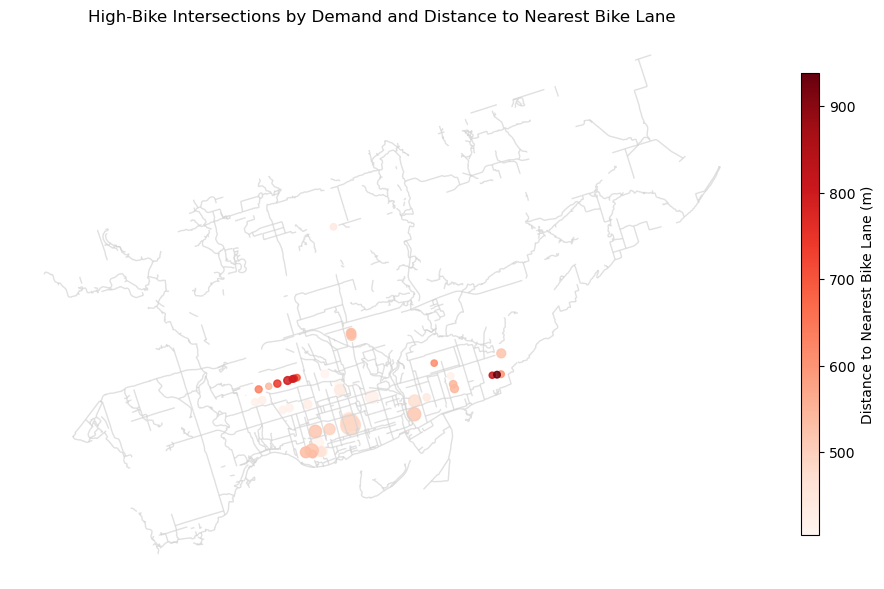

In [ ]:
#produce graph
import numpy as np
fig, ax = plt.subplots(figsize=(12, 12))


bike_lanes_gdf_3857.plot(
    ax=ax,
    color="lightgrey",
    linewidth=1,
    alpha=0.7
)


sizes = np.interp(
    nearest_uncovered_clean["avg_15min_bike"],
    (
        nearest_uncovered_clean["avg_15min_bike"].min(),
        nearest_uncovered_clean["avg_15min_bike"].max()
    ),
    (20, 200)   
)

nearest_uncovered_clean.plot(
    ax=ax,
    column="nearest_bike_lane_m",
    cmap="Reds",
    markersize=sizes,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "aspect": 25,
        "label": "Distance to Nearest Bike Lane (m)"
    },
    alpha=0.85
)

ax.set_title("High-Bike Intersections by Demand and Distance to Nearest Bike Lane")
ax.set_axis_off()

plt.savefig(
    "high_bike_intersections.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()